Keyword Extraction Using KeyBERT.

Install the relevant packages.

In [2]:
from keybert import KeyBERT

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\transformers\utils\generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\transformers\utils\generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


KeyBert starts by embedding a document into a vector by turning a chunk of text into a fixed sized vector which represents the semnatics of the document.
Extracts key words using simple techniques - count vectorizer, TFADF vectorizer
Embeds each word using the same model used to embed the document, leaving a list of keyword embeddings. 
Similarity measures will be calculated between document and keyword embeddings. This results in a vector, where each value is a similarity measure between the two. Sorts results in decreasing order to get the most simliar words. 

Adding diversity in the data:
Sometimes there is some redundancy in the data, and repetition. 
Max Sum Similarity
Maximal Marginal Relevance

In [3]:
model = KeyBERT(model = "distilbert-base-nli-mean-tokens")

One document PER Coordinate is needed for analysis

In [4]:
import pandas as pd

In [5]:
all_feedback = pd.read_csv('C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\joinedfeedback.csv')
ratings = all_feedback.loc[:, ['Latitude', 'Longitude', 'q1', 'q2', 'q3', 'q4']]
responses =  all_feedback.loc[:, ['Latitude', 'Longitude', 'responseList']]

responses

,Latitude,Longitude,responseList
0,52.285500,-1.558030,"The route was busy with the public, but there ..."
1,52.286880,-1.533620,"There was a long, isolated road with a lack of..."
2,52.279250,-1.544650,"There was a long, isolated road with a lack of..."
3,52.290777,-1.533494,The route was busy with the public as there we...
4,52.275950,-1.516430,"Well-lit street, was quite busy with other mem..."
...,...,...,...
779,52.292370,-1.548190,A really nice walk to do in the evening.; The ...
780,52.285970,-1.536280,The route felt fairly safe with some street li...
781,52.282960,-1.545510,The route felt fairly safe with some street li...
782,52.288400,-1.538270,Walking through the park made me feel uneasy a...


Need to classify each coordinate to be safe/unsafe utilising user feedback. Used average of all answers to question 1 "How safe did you feel on the route?" 

In [6]:
classification_list = []
for index, row in ratings.iterrows():
    if row["q1"] > 2.5:
        classification_list.append("safe")
    else:
        classification_list.append("unsafe")

ratings["Classification"] = classification_list

ratings
ratings["Classification"].value_counts()

Classification
safe      413
unsafe    371
Name: count, dtype: int64

In [7]:
ratings['q2'] = ratings['q2'] / 5
ratings['q3'] = ratings['q3'] / 5
ratings['q4'] = ratings['q4'] / 5


In [8]:
ratings

,Latitude,Longitude,q1,q2,q3,q4,Classification
0,52.285500,-1.558030,3.0,0.80,0.80,0.20,safe
1,52.286880,-1.533620,3.0,0.60,0.40,0.20,safe
2,52.279250,-1.544650,3.0,0.60,0.40,0.20,safe
3,52.290777,-1.533494,3.5,0.75,0.80,0.35,safe
4,52.275950,-1.516430,3.0,0.60,0.60,0.20,safe
...,...,...,...,...,...,...,...
779,52.292370,-1.548190,3.0,0.55,0.65,0.40,safe
780,52.285970,-1.536280,2.5,0.40,0.30,0.20,unsafe
781,52.282960,-1.545510,2.5,0.40,0.30,0.20,unsafe
782,52.288400,-1.538270,2.0,0.40,0.20,0.20,unsafe


In [9]:
from keyphrase_vectorizers import KeyphraseCountVectorizer

In [10]:
keywords_list = []

for index, row in responses.iterrows():
  
    doc = row["responseList"]

    keywords = model.extract_keywords(doc, keyphrase_ngram_range=(1,2), stop_words='english', use_mmr=True, diversity=0.9)

    keywords_list.append(keywords)

responses['Keywords 2'] = keywords_list
    

In [11]:
keywords_list = []

for index, row in responses.iterrows():
  
    doc = row["responseList"]

    keywords = model.extract_keywords(doc, keyphrase_ngram_range=(1,1), stop_words='english', use_mmr=True, diversity=0.9)

    keywords_list.append(keywords)

responses['Keywords'] = keywords_list

In [12]:
keywords_list = []

for index, row in responses.iterrows():
  
    doc = row["responseList"]

    keywords = model.extract_keywords(doc, keyphrase_ngram_range=(1,3), stop_words='english', use_mmr=True, diversity=0.9)

    keywords_list.append(keywords)

responses['Keywords 3'] = keywords_list

In [13]:
keywords_list = []

for index, row in responses.iterrows():
  
    doc = row["responseList"]

    keywords = model.extract_keywords(doc, vectorizer=KeyphraseCountVectorizer(), stop_words='english', use_mmr=True, diversity=0.9)

    keywords_list.append(keywords)

responses['Keywords V'] = keywords_list

In [14]:
print(keywords_list)

[[('cars', 0.3133), ('public', 0.1818), ('lot', 0.1286), ('times', 0.0115), ('route', 0.003)], [('isolated road', 0.7717), ('lack', 0.5557), ('route', 0.3725), ('lighting', 0.3005)], [('isolated road', 0.7717), ('lack', 0.5557), ('route', 0.3725), ('lighting', 0.3005)], [('many shops', 0.474), ('parade', 0.3846), ('public spaces', 0.3356), ('safer choice', 0.2828), ('lots', 0.0595)], [('street', 0.5627), ('public', 0.5542), ('other members', 0.4653)], [('isolated road', 0.7717), ('lack', 0.5557), ('route', 0.3725), ('lighting', 0.3005)], [('street lighting', 0.3342), ('road', 0.2989), ('public spaces', 0.21), ('route', 0.1095), ('access', 0.0537)], [('cars', 0.3133), ('public', 0.1818), ('lot', 0.1286), ('times', 0.0115), ('route', 0.003)], [('busy route', 0.3729), ('cars', 0.1932), ('hospital', 0.1045), ('shops', 0.0952), ('times', -0.1172)], [('cars', 0.3133), ('public', 0.1818), ('lot', 0.1286), ('times', 0.0115), ('route', 0.003)], [('unlit roads', 0.4342), ('route', 0.1826)], [('c

In [15]:
responses

,Latitude,Longitude,responseList,Keywords 2,Keywords,Keywords 3,Keywords V
0,52.285500,-1.558030,"The route was busy with the public, but there ...","[(busy public, 0.5604), (lot cars, 0.3592), (u...","[(busy, 0.3785), (unsafe, 0.3211), (cars, 0.31...","[(cars feel unsafe, 0.7099), (busy public, 0.5...","[(cars, 0.3133), (public, 0.1818), (lot, 0.128..."
1,52.286880,-1.533620,"There was a long, isolated road with a lack of...","[(isolated road, 0.7717), (long isolated, 0.65...","[(isolated, 0.57), (road, 0.5312), (long, 0.45...","[(long isolated road, 0.8514), (lack lighting ...","[(isolated road, 0.7717), (lack, 0.5557), (rou..."
2,52.279250,-1.544650,"There was a long, isolated road with a lack of...","[(isolated road, 0.7717), (long isolated, 0.65...","[(isolated, 0.57), (road, 0.5312), (long, 0.45...","[(long isolated road, 0.8514), (lack lighting ...","[(isolated road, 0.7717), (lack, 0.5557), (rou..."
3,52.290777,-1.533494,The route was busy with the public as there we...,"[(parade safer, 0.4993), (shops needed, 0.3651...","[(parade, 0.3846), (shops, 0.2816), (nearby, 0...","[(busy public shops, 0.5989), (parade, 0.3846)...","[(many shops, 0.474), (parade, 0.3846), (publi..."
4,52.275950,-1.516430,"Well-lit street, was quite busy with other mem...","[(lit street, 0.7497), (busy members, 0.6292),...","[(street, 0.5627), (public, 0.5542), (busy, 0....","[(public lit street, 0.7701), (street quite bu...","[(street, 0.5627), (public, 0.5542), (other me..."
...,...,...,...,...,...,...,...
779,52.292370,-1.548190,A really nice walk to do in the evening.; The ...,"[(night drunk, 0.5259), (short sweet, 0.2917),...","[(drunk, 0.3404), (short, 0.2023), (12am, 0.13...","[(park night drunk, 0.5805), (poorly lit 12am,...","[(many drunk people, 0.4018), (night, 0.2683),..."
780,52.285970,-1.536280,The route felt fairly safe with some street li...,"[(felt helpless, 0.381), (night route, 0.3066)...","[(helpless, 0.3453), (night, 0.2396), (park, 0...","[(park felt helpless, 0.581), (night route, 0....","[(street lighting, 0.3024), (nobody, 0.2774), ..."
781,52.282960,-1.545510,The route felt fairly safe with some street li...,"[(felt helpless, 0.381), (night route, 0.3066)...","[(helpless, 0.3453), (night, 0.2396), (park, 0...","[(park felt helpless, 0.581), (night route, 0....","[(street lighting, 0.3024), (nobody, 0.2774), ..."
782,52.288400,-1.538270,Walking through the park made me feel uneasy a...,"[(uneasy lighting, 0.5117), (walking park, 0.4...","[(uneasy, 0.404), (walking, 0.3186), (park, 0....","[(park feel uneasy, 0.6819), (uneasy lighting,...","[(park, 0.3162), (paths, 0.2046), (lighting, 0..."


In [16]:
combined_df = pd.merge(ratings, responses, on=["Latitude", "Longitude"])

In [17]:
combined_df

,Latitude,Longitude,q1,q2,q3,q4,Classification,responseList,Keywords 2,Keywords,Keywords 3,Keywords V
0,52.285500,-1.558030,3.0,0.80,0.80,0.20,safe,"The route was busy with the public, but there ...","[(busy public, 0.5604), (lot cars, 0.3592), (u...","[(busy, 0.3785), (unsafe, 0.3211), (cars, 0.31...","[(cars feel unsafe, 0.7099), (busy public, 0.5...","[(cars, 0.3133), (public, 0.1818), (lot, 0.128..."
1,52.286880,-1.533620,3.0,0.60,0.40,0.20,safe,"There was a long, isolated road with a lack of...","[(isolated road, 0.7717), (long isolated, 0.65...","[(isolated, 0.57), (road, 0.5312), (long, 0.45...","[(long isolated road, 0.8514), (lack lighting ...","[(isolated road, 0.7717), (lack, 0.5557), (rou..."
2,52.279250,-1.544650,3.0,0.60,0.40,0.20,safe,"There was a long, isolated road with a lack of...","[(isolated road, 0.7717), (long isolated, 0.65...","[(isolated, 0.57), (road, 0.5312), (long, 0.45...","[(long isolated road, 0.8514), (lack lighting ...","[(isolated road, 0.7717), (lack, 0.5557), (rou..."
3,52.290777,-1.533494,3.5,0.75,0.80,0.35,safe,The route was busy with the public as there we...,"[(parade safer, 0.4993), (shops needed, 0.3651...","[(parade, 0.3846), (shops, 0.2816), (nearby, 0...","[(busy public shops, 0.5989), (parade, 0.3846)...","[(many shops, 0.474), (parade, 0.3846), (publi..."
4,52.275950,-1.516430,3.0,0.60,0.60,0.20,safe,"Well-lit street, was quite busy with other mem...","[(lit street, 0.7497), (busy members, 0.6292),...","[(street, 0.5627), (public, 0.5542), (busy, 0....","[(public lit street, 0.7701), (street quite bu...","[(street, 0.5627), (public, 0.5542), (other me..."
...,...,...,...,...,...,...,...,...,...,...,...,...
779,52.292370,-1.548190,3.0,0.55,0.65,0.40,safe,A really nice walk to do in the evening.; The ...,"[(night drunk, 0.5259), (short sweet, 0.2917),...","[(drunk, 0.3404), (short, 0.2023), (12am, 0.13...","[(park night drunk, 0.5805), (poorly lit 12am,...","[(many drunk people, 0.4018), (night, 0.2683),..."
780,52.285970,-1.536280,2.5,0.40,0.30,0.20,unsafe,The route felt fairly safe with some street li...,"[(felt helpless, 0.381), (night route, 0.3066)...","[(helpless, 0.3453), (night, 0.2396), (park, 0...","[(park felt helpless, 0.581), (night route, 0....","[(street lighting, 0.3024), (nobody, 0.2774), ..."
781,52.282960,-1.545510,2.5,0.40,0.30,0.20,unsafe,The route felt fairly safe with some street li...,"[(felt helpless, 0.381), (night route, 0.3066)...","[(helpless, 0.3453), (night, 0.2396), (park, 0...","[(park felt helpless, 0.581), (night route, 0....","[(street lighting, 0.3024), (nobody, 0.2774), ..."
782,52.288400,-1.538270,2.0,0.40,0.20,0.20,unsafe,Walking through the park made me feel uneasy a...,"[(uneasy lighting, 0.5117), (walking park, 0.4...","[(uneasy, 0.404), (walking, 0.3186), (park, 0....","[(park feel uneasy, 0.6819), (uneasy lighting,...","[(park, 0.3162), (paths, 0.2046), (lighting, 0..."


In [18]:
from collections import Counter

In [47]:
from collections import defaultdict

# Assuming combined_df is your DataFrame and it's already defined

# Explode keywords while filtering by classification
safe_keywords = combined_df[combined_df["Classification"] == "safe"]["Keywords"].explode()
unsafe_keywords = combined_df[combined_df["Classification"] == "unsafe"]["Keywords"].explode()

# Use defaultdicts to store lists of scores for each keyword
safe_keywords_scores = defaultdict(list)
unsafe_keywords_scores = defaultdict(list)

# Populate the defaultdicts with scores
for keyword, score in safe_keywords:
    safe_keywords_scores[keyword].append(score)

for keyword, score in unsafe_keywords:
    unsafe_keywords_scores[keyword].append(score)

# Create dictionaries to hold the highest score and frequency for each keyword
safe_summary = {keyword: (max(scores), len(scores)) for keyword, scores in safe_keywords_scores.items()}
unsafe_summary = {keyword: (max(scores), len(scores)) for keyword, scores in unsafe_keywords_scores.items()}

# Sort by frequency (which is the second element of the tuple in the summary) and select the top 10
top_safe_keywords = sorted(safe_summary.items(), key=lambda x: x[1][1], reverse=True)[:10]
top_unsafe_keywords = sorted(unsafe_summary.items(), key=lambda x: x[1][1], reverse=True)[:10]

print("Top 10 Safe Keywords, Scores, and Frequencies:", top_safe_keywords)
print("Top 10 Unsafe Keywords, Scores, and Frequencies:", top_unsafe_keywords)



Top 10 Safe Keywords, Scores, and Frequencies: [('busy', (0.5619, 222)), ('route', (0.3972, 176)), ('walk', (0.4291, 158)), ('public', (0.5552, 149)), ('park', (0.4643, 130)), ('safe', (0.7503, 125)), ('daytime', (0.5343, 105)), ('cars', (0.3133, 90)), ('unsafe', (0.4306, 89)), ('lighting', (0.3005, 61))]
Top 10 Unsafe Keywords, Scores, and Frequencies: [('lighting', (0.2089, 156)), ('park', (0.3162, 149)), ('night', (0.5194, 121)), ('hospital', (0.1886, 100)), ('nearby', (0.1452, 100)), ('shops', (0.1568, 99)), ('unsafe', (0.7154, 89)), ('isolated', (0.3877, 83)), ('walk', (0.1617, 74)), ('helpless', (0.3453, 73))]


In [48]:
from collections import defaultdict

# Assuming combined_df is your DataFrame and it's already defined

# Explode keywords while filtering by classification
safe_keywords = combined_df[combined_df["Classification"] == "safe"]["Keywords 2"].explode()
unsafe_keywords = combined_df[combined_df["Classification"] == "unsafe"]["Keywords 2"].explode()

# Use defaultdicts to store lists of scores for each keyword
safe_keywords_scores = defaultdict(list)
unsafe_keywords_scores = defaultdict(list)

# Populate the defaultdicts with scores
for keyword, score in safe_keywords:
    safe_keywords_scores[keyword].append(score)

for keyword, score in unsafe_keywords:
    unsafe_keywords_scores[keyword].append(score)

# Create dictionaries to hold the highest score and frequency for each keyword
safe_summary = {keyword: (max(scores), len(scores)) for keyword, scores in safe_keywords_scores.items()}
unsafe_summary = {keyword: (max(scores), len(scores)) for keyword, scores in unsafe_keywords_scores.items()}

# Sort by frequency (which is the second element of the tuple in the summary) and select the top 10
top_safe_keywords = sorted(safe_summary.items(), key=lambda x: x[1][1], reverse=True)[:10]
top_unsafe_keywords = sorted(unsafe_summary.items(), key=lambda x: x[1][1], reverse=True)[:10]

print("Top 10 Safe Keywords, Scores, and Frequencies:", top_safe_keywords)
print("Top 10 Unsafe Keywords, Scores, and Frequencies:", top_unsafe_keywords)


Top 10 Safe Keywords, Scores, and Frequencies: [('public', (0.5552, 117)), ('busy daytime', (0.5421, 106)), ('park nice', (0.6938, 97)), ('busy public', (0.5604, 95)), ('lot cars', (0.3592, 88)), ('route walk', (0.3301, 88)), ('unsafe', (0.3211, 86)), ('times route', (0.0321, 86)), ('safe', (0.4375, 86)), ('scenic', (0.416, 86))]
Top 10 Unsafe Keywords, Scores, and Frequencies: [('hospital nearby', (0.2667, 100)), ('busy route', (0.3729, 99)), ('lighting time', (0.1792, 76)), ('fairly safe', (0.1904, 75)), ('walk park', (0.2931, 70)), ('night route', (0.3066, 70)), ('felt helpless', (0.381, 67)), ('away shops', (0.4378, 66)), ('shops public', (0.2677, 66)), ('overall preferred', (0.1806, 66))]


In [49]:
from collections import defaultdict

# Assuming combined_df is your DataFrame and it's already defined

# Explode keywords while filtering by classification
safe_keywords = combined_df[combined_df["Classification"] == "safe"]["Keywords 3"].explode()
unsafe_keywords = combined_df[combined_df["Classification"] == "unsafe"]["Keywords 3"].explode()

# Use defaultdicts to store lists of scores for each keyword
safe_keywords_scores = defaultdict(list)
unsafe_keywords_scores = defaultdict(list)

# Populate the defaultdicts with scores
for keyword, score in safe_keywords:
    safe_keywords_scores[keyword].append(score)

for keyword, score in unsafe_keywords:
    unsafe_keywords_scores[keyword].append(score)

# Create dictionaries to hold the highest score and frequency for each keyword
safe_summary = {keyword: (max(scores), len(scores)) for keyword, scores in safe_keywords_scores.items()}
unsafe_summary = {keyword: (max(scores), len(scores)) for keyword, scores in unsafe_keywords_scores.items()}

# Sort by frequency (which is the second element of the tuple in the summary) and select the top 10
top_safe_keywords = sorted(safe_summary.items(), key=lambda x: x[1][1], reverse=True)[:10]
top_unsafe_keywords = sorted(unsafe_summary.items(), key=lambda x: x[1][1], reverse=True)[:10]

print("Top 10 Safe Keywords, Scores, and Frequencies:", top_safe_keywords)
print("Top 10 Unsafe Keywords, Scores, and Frequencies:", top_unsafe_keywords)


Top 10 Safe Keywords, Scores, and Frequencies: [('route', (0.2669, 102)), ('park', (0.4643, 93)), ('daytime felt safe', (0.6322, 89)), ('cars feel unsafe', (0.7719, 88)), ('busy daytime', (0.3986, 88)), ('times route', (0.0321, 87)), ('busy public', (0.5604, 86)), ('lot cars', (0.3592, 86)), ('unsafe', (0.3211, 86)), ('walk park nice', (0.7759, 86))]
Top 10 Unsafe Keywords, Scores, and Frequencies: [('park', (0.3162, 125)), ('away shops public', (0.5348, 100)), ('hospital nearby', (0.2667, 100)), ('park felt helpless', (0.581, 70)), ('night route', (0.3066, 68)), ('street lighting time', (0.2877, 68)), ('felt fairly safe', (0.2228, 68)), ('overall preferred busy', (0.3259, 67)), ('safe', (0.2519, 66)), ('spaces hospital', (0.2223, 66))]


following code is to alter safety score based on presence of words:

In [50]:
from collections import defaultdict

# Assuming combined_df is your DataFrame and it's already defined

# Explode keywords while filtering by classification
safe_keywords = combined_df[combined_df["Classification"] == "safe"]["Keywords V"].explode()
unsafe_keywords = combined_df[combined_df["Classification"] == "unsafe"]["Keywords V"].explode()

# Use defaultdicts to store lists of scores for each keyword
safe_keywords_scores = defaultdict(list)
unsafe_keywords_scores = defaultdict(list)

# Populate the defaultdicts with scores
for keyword, score in safe_keywords:
    safe_keywords_scores[keyword].append(score)

for keyword, score in unsafe_keywords:
    unsafe_keywords_scores[keyword].append(score)

# Create dictionaries to hold the highest score and frequency for each keyword
safe_summary = {keyword: (max(scores), len(scores)) for keyword, scores in safe_keywords_scores.items()}
unsafe_summary = {keyword: (max(scores), len(scores)) for keyword, scores in unsafe_keywords_scores.items()}

# Sort by frequency (which is the second element of the tuple in the summary) and select the top 10
top_safe_keywords = sorted(safe_summary.items(), key=lambda x: x[1][1], reverse=True)[:10]
top_unsafe_keywords = sorted(unsafe_summary.items(), key=lambda x: x[1][1], reverse=True)[:10]

print("Top 10 Safe Keywords, Scores, and Frequencies:", top_safe_keywords)
print("Top 10 Unsafe Keywords, Scores, and Frequencies:", top_unsafe_keywords)

Top 10 Safe Keywords, Scores, and Frequencies: [('route', (0.3972, 243)), ('park', (0.4643, 125)), ('public', (0.5542, 124)), ('daytime', (0.5343, 112)), ('scenic route', (0.5427, 100)), ('walk', (0.2866, 100)), ('cars', (0.3133, 88)), ('lot', (0.1286, 87)), ('times', (0.0115, 86)), ('felt', (0.1426, 86))]
Top 10 Unsafe Keywords, Scores, and Frequencies: [('route', (0.2682, 234)), ('park', (0.3162, 149)), ('night', (0.5194, 123)), ('hospital', (0.1886, 100)), ('shops', (0.1568, 100)), ('busy route', (0.3729, 99)), ('street lighting', (0.3342, 85)), ('public spaces', (0.21, 74)), ('lighting', (0.2089, 71)), ('nobody', (0.2774, 70))]


In [51]:
import pandas as pd
from operator import itemgetter

# Assuming combined_df is your DataFrame and it's already defined

# Explode keywords while filtering by classification
safe_keywords = combined_df[combined_df["Classification"] == "safe"]["Keywords"].explode()
unsafe_keywords = combined_df[combined_df["Classification"] == "unsafe"]["Keywords"].explode()

# Use a dictionary to keep the highest relevance score for each unique keyword
safe_keywords_dict = {}
unsafe_keywords_dict = {}

for keyword, score in safe_keywords:
    if keyword not in safe_keywords_dict or safe_keywords_dict[keyword] < score:
        safe_keywords_dict[keyword] = score

for keyword, score in unsafe_keywords:
    if keyword not in unsafe_keywords_dict or unsafe_keywords_dict[keyword] < score:
        unsafe_keywords_dict[keyword] = score

# Sort the dictionaries by score and select the top 10 unique keywords
top_safe_keywords = sorted(safe_keywords_dict.items(), key=lambda x: x[1], reverse=True)[:10]
top_unsafe_keywords = sorted(unsafe_keywords_dict.items(), key=lambda x: x[1], reverse=True)[:10]

# Extract just the words for presentation
top_safe_words = [keyword for keyword, _ in top_safe_keywords]
top_unsafe_words = [keyword for keyword, _ in top_unsafe_keywords]

print("Top 10 Safe Words:", top_safe_keywords)
print("Top 10 Unsafe Words:", top_unsafe_keywords)


Top 10 Safe Words: [('safe', 0.7503), ('residential', 0.7119), ('ease', 0.6544), ('isolated', 0.57), ('street', 0.5627), ('busy', 0.5619), ('public', 0.5552), ('afternoons', 0.5527), ('daytime', 0.5343), ('road', 0.5312)]
Top 10 Unsafe Words: [('quiet', 0.7847), ('unsafe', 0.7154), ('drunk', 0.6861), ('terrible', 0.6186), ('dark', 0.53), ('night', 0.5194), ('away', 0.4561), ('public', 0.4321), ('poorly', 0.4299), ('road', 0.4159)]


In [52]:
import pandas as pd
from operator import itemgetter

# Assuming combined_df is your DataFrame and it's already defined

# Explode keywords while filtering by classification
safe_keywords = combined_df[combined_df["Classification"] == "safe"]["Keywords 2"].explode()
unsafe_keywords = combined_df[combined_df["Classification"] == "unsafe"]["Keywords 2"].explode()

# Use a dictionary to keep the highest relevance score for each unique keyword
safe_keywords_dict = {}
unsafe_keywords_dict = {}

for keyword, score in safe_keywords:
    if keyword not in safe_keywords_dict or safe_keywords_dict[keyword] < score:
        safe_keywords_dict[keyword] = score

for keyword, score in unsafe_keywords:
    if keyword not in unsafe_keywords_dict or unsafe_keywords_dict[keyword] < score:
        unsafe_keywords_dict[keyword] = score

# Sort the dictionaries by score and select the top 10 unique keywords
top_safe_keywords = sorted(safe_keywords_dict.items(), key=lambda x: x[1], reverse=True)[:10]
top_unsafe_keywords = sorted(unsafe_keywords_dict.items(), key=lambda x: x[1], reverse=True)[:10]

# Extract just the words for presentation
top_safe_words = [keyword for keyword, _ in top_safe_keywords]
top_unsafe_words = [keyword for keyword, _ in top_unsafe_keywords]

print("Top 10 Safe Words:", top_safe_keywords)
print("Top 10 Unsafe Words:", top_unsafe_keywords)

Top 10 Safe Words: [('safe access', 0.8528), ('isolated road', 0.7717), ('lots public', 0.7591), ('lit street', 0.7497), ('residential', 0.7119), ('park nice', 0.6938), ('enjoyable evening', 0.6922), ('felt fairly', 0.6885), ('ease route', 0.6862), ('evening walk', 0.6812)]
Top 10 Unsafe Words: [('quiet route', 0.8177), ('drunk people', 0.7913), ('roads poorly', 0.7913), ('terrible dark', 0.7726), ('road lack', 0.7677), ('lots drunk', 0.7309), ('unsafe residential', 0.7215), ('feels unsafe', 0.676), ('streets dark', 0.672), ('night drunk', 0.6594)]


In [53]:
import pandas as pd
from operator import itemgetter

# Assuming combined_df is your DataFrame and it's already defined

# Explode keywords while filtering by classification
safe_keywords = combined_df[combined_df["Classification"] == "safe"]["Keywords 3"].explode()
unsafe_keywords = combined_df[combined_df["Classification"] == "unsafe"]["Keywords 3"].explode()

# Use a dictionary to keep the highest relevance score for each unique keyword
safe_keywords_dict = {}
unsafe_keywords_dict = {}

for keyword, score in safe_keywords:
    if keyword not in safe_keywords_dict or safe_keywords_dict[keyword] < score:
        safe_keywords_dict[keyword] = score

for keyword, score in unsafe_keywords:
    if keyword not in unsafe_keywords_dict or unsafe_keywords_dict[keyword] < score:
        unsafe_keywords_dict[keyword] = score

# Sort the dictionaries by score and select the top 10 unique keywords
top_safe_keywords = sorted(safe_keywords_dict.items(), key=lambda x: x[1], reverse=True)[:10]
top_unsafe_keywords = sorted(unsafe_keywords_dict.items(), key=lambda x: x[1], reverse=True)[:10]

# Extract just the words for presentation
top_safe_words = [keyword for keyword, _ in top_safe_keywords]
top_unsafe_words = [keyword for keyword, _ in top_unsafe_keywords]

print("Top 10 Safe Words:", top_safe_keywords)
print("Top 10 Unsafe Words:", top_unsafe_keywords)


Top 10 Safe Words: [('ease route residential', 0.872), ('fairly safe access', 0.8703), ('long isolated road', 0.8514), ('lit busy lots', 0.8342), ('enjoyable evening walk', 0.8297), ('busy people restaurants', 0.7897), ('walk park nice', 0.7759), ('cars feel unsafe', 0.7719), ('public lit street', 0.7701), ('street quite busy', 0.7673)]
Top 10 Unsafe Words: [('unsafe especially night', 0.8677), ('road lack lighting', 0.8534), ('quiet route public', 0.8391), ('streets feels unsafe', 0.8365), ('roads poorly lit', 0.8281), ('terrible dark unlit', 0.8118), ('lots drunk people', 0.7978), ('park felt unsafe', 0.7655), ('unsafe residential access', 0.7517), ('evening felt unsafe', 0.7467)]


In [54]:
import pandas as pd
from operator import itemgetter

# Assuming combined_df is your DataFrame and it's already defined

# Explode keywords while filtering by classification
safe_keywords = combined_df[combined_df["Classification"] == "safe"]["Keywords V"].explode()
unsafe_keywords = combined_df[combined_df["Classification"] == "unsafe"]["Keywords V"].explode()

# Use a dictionary to keep the highest relevance score for each unique keyword
safe_keywords_dict = {}
unsafe_keywords_dict = {}

for keyword, score in safe_keywords:
    if keyword not in safe_keywords_dict or safe_keywords_dict[keyword] < score:
        safe_keywords_dict[keyword] = score

for keyword, score in unsafe_keywords:
    if keyword not in unsafe_keywords_dict or unsafe_keywords_dict[keyword] < score:
        unsafe_keywords_dict[keyword] = score

# Sort the dictionaries by score and select the top 10 unique keywords
top_safe_keywords = sorted(safe_keywords_dict.items(), key=lambda x: x[1], reverse=True)[:10]
top_unsafe_keywords = sorted(unsafe_keywords_dict.items(), key=lambda x: x[1], reverse=True)[:10]

# Extract just the words for presentation
top_safe_words = [keyword for keyword, _ in top_safe_keywords]
top_unsafe_words = [keyword for keyword, _ in top_unsafe_keywords]

print("Top 10 Safe Words:", top_safe_keywords)
print("Top 10 Unsafe Words:", top_unsafe_keywords)


Top 10 Safe Words: [('enjoyable evening walk', 0.8297), ('isolated road', 0.7717), ('many restaurants', 0.7204), ('street lights', 0.6739), ('busy streets', 0.6722), ('ease', 0.6544), ('nice walk', 0.6337), ('public spaces', 0.6254), ('little street lighting', 0.5852), ('good street lighting', 0.5777)]
Top 10 Unsafe Words: [('quiet route', 0.8177), ('drunk people', 0.7913), ('isolated road', 0.7589), ('many drunk people', 0.6006), ('lack', 0.5561), ('night', 0.5194), ('isolated streets', 0.509), ('unlit roads', 0.478), ('little lighting', 0.4605), ('round back streets', 0.4449)]


Getting crime data for this dataframe - creating new safety scores. 

In [55]:
crime_severity_scores = {
    "Drugs" : 2,
    "Shoplifting" : 2,
    "Burglary" : 5,
    "Theft from the person" : 8,
    "Possession of weapons" : 9,
    "Violence and sexual offences" : 10,
    "Criminal damage and arson" : 7,
    "Vehicle crime" : 4,
    "Bicycle theft " : 2,
    "Other theft" : 1,
    "Public order" : 1,
    "Robbery" : 5, 
    "Anti-social behaviour" : 5,
    "Other crime" : 1
}

In [56]:
import numpy as np 

In [57]:
def get_lat_lon_ranges(lat, lon, radius):
    # Earth's radius in meters
    EARTH_RADIUS = 6378137

    # Convert latitude and longitude from degrees to radians
    lat_rad = np.radians(lat)

    # Calculate deltas
    dLat = radius/EARTH_RADIUS
    dLon = radius/(EARTH_RADIUS * np.cos(lat_rad))

    # Convert deltas from radians to degrees
    dLat_deg = np.degrees(dLat)
    dLon_deg = np.degrees(dLon)

    # Define ranges
    lat_range = (lat - dLat_deg, lat + dLat_deg)
    lon_range = (lon - dLon_deg, lon + dLon_deg)

    return lat_range, lon_range

In [80]:
def get_crimes_in_range(all_crime_data, long_min, long_max, lat_min, lat_max, crime_severity_scores):
    # Filter the data to only include crimes within the specified ranges
    crimes_in_range = all_crime_data[
        (all_crime_data['Longitude'] >= long_min) & 
        (all_crime_data['Longitude'] <= long_max) & 
        (all_crime_data['Latitude'] >= lat_min) & 
        (all_crime_data['Latitude'] <= lat_max)
    ]

    crimes_in_range = crimes_in_range.copy()

    crimes_in_range['Severity Score'] = crimes_in_range['Crime type'].map(crime_severity_scores)

    if not crimes_in_range.empty:
        average_severity_score = crimes_in_range['Severity Score'].mean()
    else:
        average_severity_score = 0

    return len(crimes_in_range), average_severity_score

In [98]:
def get_public_spaces_in_range(all_public_spaces, long_min, long_max, lat_min, lat_max):
    # Filter the data to only include crimes within the specified ranges
    places_in_range = all_public_spaces[
        (all_public_spaces['Longitude'] >= long_min) & 
        (all_public_spaces['Longitude'] <= long_max) & 
        (all_public_spaces['Latitude'] >= lat_min) & 
        (all_public_spaces['Latitude'] <= lat_max)
    ]

    return len(places_in_range)

In [82]:
crime_data_2021 = pd.read_csv("C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\crimes_in_range_2021.csv")
crime_data_2022 = pd.read_csv("C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\crimes_in_range_2022.csv")
crime_data_2023 = pd.read_csv("C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\crimes_in_range_2023.csv")
all_public_space_data = pd.read_csv("C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\public_spaces_data_350.csv")

In [83]:
def get_coords(dataframe):
    all_locations = [f"{row['Latitude']}, {row['Longitude']}" for index, row in dataframe.iterrows()]
    return [(float(lat), float(lon)) for lat, lon in (s.split(', ') for s in all_locations)]

coords = get_coords(combined_df)

print(len(coords))
coords

784


[(52.2855, -1.55803),
 (52.28688, -1.53362),
 (52.27925, -1.54465),
 (52.290777, -1.533494),
 (52.27595, -1.51643),
 (52.28569, -1.53394),
 (52.2760706, -1.5164124),
 (52.28398, -1.53755),
 (52.2913, -1.57789),
 (52.28414, -1.53665),
 (52.2843, -1.53489),
 (52.28377, -1.5404),
 (52.2866, -1.54848),
 (52.29140349999999, -1.5782611),
 (52.28624, -1.53316),
 (52.2818, -1.53485),
 (52.28959, -1.55339),
 (52.2851, -1.56291),
 (52.2762849, -1.5356019),
 (52.28728, -1.53574),
 (52.28541, -1.55786),
 (52.28725, -1.53562),
 (52.2899, -1.53796),
 (52.28806, -1.56727),
 (52.28694, -1.53704),
 (52.27543, -1.52666),
 (52.28681, -1.56078),
 (52.2948, -1.53725),
 (52.27632, -1.5322),
 (52.28503, -1.53542),
 (52.28789, -1.54591),
 (52.2875364, -1.541341),
 (52.27641, -1.52057),
 (52.28444, -1.53546),
 (52.28617, -1.55979),
 (52.28582, -1.53308),
 (52.29094, -1.57684),
 (52.28051, -1.53824),
 (52.28776, -1.56568),
 (52.28514, -1.53637),
 (52.2907119, -1.5829859),
 (52.28552, -1.56332),
 (52.29034, -1.5

In [99]:
def create_dict(all_crime_data, all_public_space_data, all_coordinates, crime_severity_scores):
    coordinate_dict = {}
    for each in all_coordinates:
        coordinate_dict[each] = [0, 0, 0]
        # Gets lat/lon range within a 50m radius
        lat_range, lon_range = get_lat_lon_ranges(each[0], each[1], 250)
        coordinate_dict[each][0], coordinate_dict[each][1] = get_crimes_in_range(all_crime_data, lon_range[0], lon_range[1], lat_range[0], lat_range[1], crime_severity_scores)
        coordinate_dict[each][2] = get_public_spaces_in_range(all_public_space_data, lon_range[0], lon_range[1], lat_range[0], lat_range[1])
    return coordinate_dict

In [112]:
data_2021 = create_dict(crime_data_2021, all_public_space_data, coords, crime_severity_scores)
data_2022 = create_dict(crime_data_2021, all_public_space_data, coords, crime_severity_scores)
data_2023 = create_dict(crime_data_2021, all_public_space_data, coords, crime_severity_scores)

In [113]:
data_2021

{(52.2855, -1.55803): [5, 6.0, 0],
 (52.28688, -1.53362): [622, 6.2901639344262295, 31],
 (52.27925, -1.54465): [60, 5.566666666666666, 10],
 (52.290777, -1.533494): [783, 4.902275769745649, 56],
 (52.27595, -1.51643): [98, 6.204081632653061, 5],
 (52.28569, -1.53394): [511, 6.351297405189621, 56],
 (52.2760706, -1.5164124): [102, 6.264705882352941, 5],
 (52.28398, -1.53755): [301, 6.285234899328859, 4],
 (52.2913, -1.57789): [0, 0, 1],
 (52.28414, -1.53665): [380, 6.874666666666666, 18],
 (52.2843, -1.53489): [543, 6.5111940298507465, 45],
 (52.28377, -1.5404): [164, 5.574074074074074, 0],
 (52.2866, -1.54848): [34, 5.294117647058823, 2],
 (52.29140349999999, -1.5782611): [0, 0, 0],
 (52.28624, -1.53316): [571, 6.265124555160142, 46],
 (52.2818, -1.53485): [252, 6.350597609561753, 19],
 (52.28959, -1.55339): [66, 5.96969696969697, 0],
 (52.2851, -1.56291): [62, 4.306451612903226, 4],
 (52.2762849, -1.5356019): [212, 5.785714285714286, 2],
 (52.28728, -1.53574): [495, 6.278008298755187

Defines the weightings used to find the safety score.

In [118]:
# Original weights based on percentages
survey_weightings = {
    "crime": 95.9,
    "emergency": 80.2,
    "crowded": 78.2,
    "lighting": 85.4,
    "public_spaces": 74.5,
    "pos_keywords": 10, # Gave a percentage of 10 to start with. 
    "neg_keywords": -10, # Gave a percentage of 10 to start with. 
    "daytime_bonus": 5
}

# Sum of the original weights
total_weight = sum(survey_weightings.values())

# Normalize each weight
normalized_weights = {k: v / total_weight for k, v in survey_weightings.items()}

print(normalized_weights)

{'crime': 0.22876908396946563, 'emergency': 0.19131679389312975, 'crowded': 0.18654580152671754, 'lighting': 0.2037213740458015, 'public_spaces': 0.17771946564885494, 'pos_keywords': 0.023854961832061067, 'neg_keywords': -0.023854961832061067, 'daytime_bonus': 0.011927480916030533}


In [119]:
# Function to calculate the safety score of a particular coordinate
def calculate_safety_score(max_crime, num_crime, emergency_rating, crowd_rating, 
                           unlit_rating, public_spaces, max_spaces, severity, weightings, keywords, pos_keywords, neg_keywords):
    
    safety_score = 0

    if num_crime > 0:
        safety_score += ((max_crime - num_crime) / max_crime) * weightings["crime"] * ((10 - severity) / 10)
    else:
        safety_score += weightings["crime"]

    if public_spaces > 0:
        safety_score += ((public_spaces / max_spaces) * weightings["public_spaces"])
    else: 
        safety_score + weightings["public_spaces"]

    if emergency_rating > 0:
        safety_score += (emergency_rating * weightings["emergency"])
    else: 
        safety_score -= weightings["emergency"]

    if crowd_rating > 0:
        safety_score += (crowd_rating * weightings["crowded"])
    else: 
        safety_score -= weightings["crowded"]

    if unlit_rating > 0:
        safety_score += (unlit_rating * weightings["lighting"])
    else: 
        safety_score -= weightings["lighting"]

    pos_count = sum(keywords.count(word) for word in pos_keywords)
    neg_count = sum(keywords.count(word) for word in neg_keywords)

    if pos_count > 0:
        pos_ratio = pos_count / len(pos_keywords)
        safety_score += (pos_ratio * weightings["pos_keywords"])

    if neg_count > 0:
        neg_ratio = neg_count / len(neg_keywords)
        safety_score += (neg_ratio * weightings["neg_keywords"])

    return safety_score * 100, pos_ratio, neg_ratio

In [120]:
def get_safety_scores(coords, max_crime, max_spaces, user_feedback, weightings, 
                      pos_keywords, neg_keywords, year, current_scores, output_file):
    safety_scores = []
    for coordinate, (crime_num, severity, public_spaces) in coords.items():
        lat = coordinate[0]
        lon = coordinate[1]

        emergency_rating = 0
        crowd_rating = 0
        unlit_rating = 0
        matching_rows = user_feedback[(user_feedback["Longitude"] == lon) & (user_feedback["Latitude"] == lat)]

        if not matching_rows.empty:
            # Assuming you want the value from the first matching row
            unlit_rating = matching_rows["q2"].iloc[0]
            crowd_rating = matching_rows["q3"].iloc[0]
            emergency_rating = matching_rows["q4"].iloc[0]
            total_keywords = matching_rows["Keywords V"].iloc[0]

            # Extract just the words, ignoring relevancy scores
            keywords = [keyword[0] for keyword in total_keywords]            

        safety_score, pos_ratio, neg_ratio = calculate_safety_score(max_crime, crime_num, emergency_rating, 
                                              crowd_rating, unlit_rating, public_spaces, max_spaces, severity, 
                                              weightings, keywords, pos_keywords, neg_keywords)
        
        safety_scores.append({
            "Latitude": lat,
            "Longitude": lon,
            "Lighting Rating": (unlit_rating / 5) * weightings["lighting"],
            "Crowd Rating": (crowd_rating / 5) * weightings["crowded"],
            "Emergency Rating": (emergency_rating / 5) * weightings["emergency"],
            "Crime Rate": ((max_crime - crime_num) / max_crime) * weightings["crime"],
            "Severity Score": (10 - severity) / 10,
            "Public Space Score": (public_spaces / max_spaces) * weightings["public_spaces"],
            "Feedback Bonus": (pos_ratio * weightings["pos_keywords"]) + (neg_ratio * weightings["neg_keywords"]),
            "Year": year,
            "Safety Score": safety_score
        })

    safety_df = pd.DataFrame(safety_scores)
    existing_df = pd.read_csv(current_scores)
    joined_df = pd.concat([existing_df, safety_df], ignore_index=True)
    joined_df.to_csv(output_file, index=False)

In [124]:
output_file = "C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\training_set_after.csv"
max_spaces = len(all_public_space_data)
top_safe_words = [('safe', 0.7503), 
('many restaurants', 0.7204), 
('residential', 0.7119), 
('ease', 0.6544), 
('public spaces', 0.6254), 
('good street lighting', 0.5777),
('busy', 0.5619), 
('afternoons', 0.5527), 
('daytime', 0.5343), 
('park', (0.4643))]

top_unsafe_words = [('quiet', 0.7847),
('unsafe', 0.7154), 
('drunk people', 0.7913), 
('terrible', 0.6186),
('dark', 0.53), 
('night', 0.5194), 
('isolated', 0.4561), 
('back streets', 0.4449),
('little lighting', 0.4605), 
('unlit roads', 0.478)]


output_df = get_safety_scores(data_2021, len(crime_data_2021), max_spaces, combined_df, normalized_weights, 
                  top_safe_words, top_unsafe_words, 2021, output_file, output_file)

output_df2 = get_safety_scores(data_2022, len(crime_data_2022), max_spaces, combined_df, normalized_weights, 
                  top_safe_words, top_unsafe_words, 2022, output_file, output_file)

get_safety_scores(data_2023, len(crime_data_2023), max_spaces, combined_df, normalized_weights, 
                  top_safe_words, top_unsafe_words, 2023, output_file, output_file)

output = pd.read_csv(output_file)

output

,Latitude,Longitude,Safety Score,Year,Lighting Rating,Crowd Rating,Emergency Rating,Crime Rate,Severity Score,Public Space Score
0,52.285500,-1.558030,44.190643,2021,0.032595,0.029847,0.007653,0.228573,0.400000,0.000000
1,52.286880,-1.533620,32.811247,2021,0.024447,0.014924,0.007653,0.204416,0.370984,0.017163
2,52.279250,-1.544650,34.103044,2021,0.024447,0.014924,0.007653,0.226420,0.443333,0.005536
3,52.290777,-1.533494,50.098488,2021,0.030558,0.029847,0.013392,0.198113,0.509772,0.031004
4,52.275950,-1.516430,36.057428,2021,0.024447,0.022385,0.007653,0.224932,0.379592,0.002768
...,...,...,...,...,...,...,...,...,...,...
2347,52.292370,-1.548190,41.965680,2023,0.022409,0.024251,0.015305,0.223807,0.480833,0.002215
2348,52.285970,-1.536280,25.853773,2023,0.016298,0.011193,0.007653,0.214529,0.318966,0.014395
2349,52.282960,-1.545510,31.225692,2023,0.016298,0.011193,0.007653,0.223081,0.602143,0.002215
2350,52.288400,-1.538270,26.129481,2023,0.016298,0.007462,0.007653,0.215659,0.414013,0.014948


In [ ]:
data_2021

{(52.2855, -1.55803): [5, 6.0],
 (52.28688, -1.53362): [622, 6.2901639344262295],
 (52.27925, -1.54465): [60, 5.566666666666666],
 (52.290777, -1.533494): [783, 4.902275769745649],
 (52.27595, -1.51643): [98, 6.204081632653061],
 (52.28569, -1.53394): [511, 6.351297405189621],
 (52.2760706, -1.5164124): [102, 6.264705882352941],
 (52.28398, -1.53755): [301, 6.285234899328859],
 (52.2913, -1.57789): [0, 0],
 (52.28414, -1.53665): [380, 6.874666666666666],
 (52.2843, -1.53489): [543, 6.5111940298507465],
 (52.28377, -1.5404): [164, 5.574074074074074],
 (52.2866, -1.54848): [34, 5.294117647058823],
 (52.29140349999999, -1.5782611): [0, 0],
 (52.28624, -1.53316): [571, 6.265124555160142],
 (52.2818, -1.53485): [252, 6.350597609561753],
 (52.28959, -1.55339): [66, 5.96969696969697],
 (52.2851, -1.56291): [62, 4.306451612903226],
 (52.2762849, -1.5356019): [212, 5.785714285714286],
 (52.28728, -1.53574): [495, 6.278008298755187],
 (52.28541, -1.55786): [5, 6.0],
 (52.28725, -1.53562): [497, 

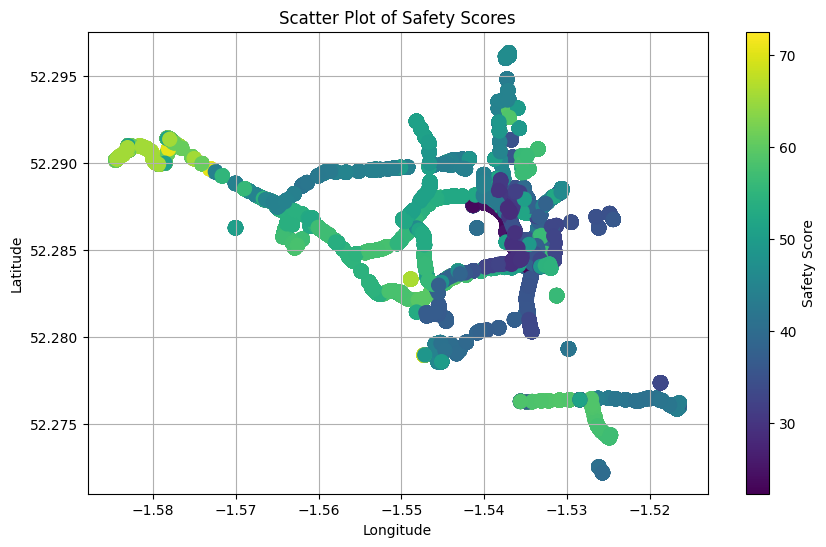

In [ ]:
import matplotlib.pyplot as plt

# Example DataFrame
df = pd.read_csv(output_file)
plt.figure(figsize=(10, 6))

# Scatter plot for safety scores
plt.scatter(df['Longitude'], df['Latitude'], c=df['Safety Score'], cmap='viridis', s=100)  # s is size
plt.colorbar(label='Safety Score')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Scatter Plot of Safety Scores')
plt.grid(True)
plt.show()

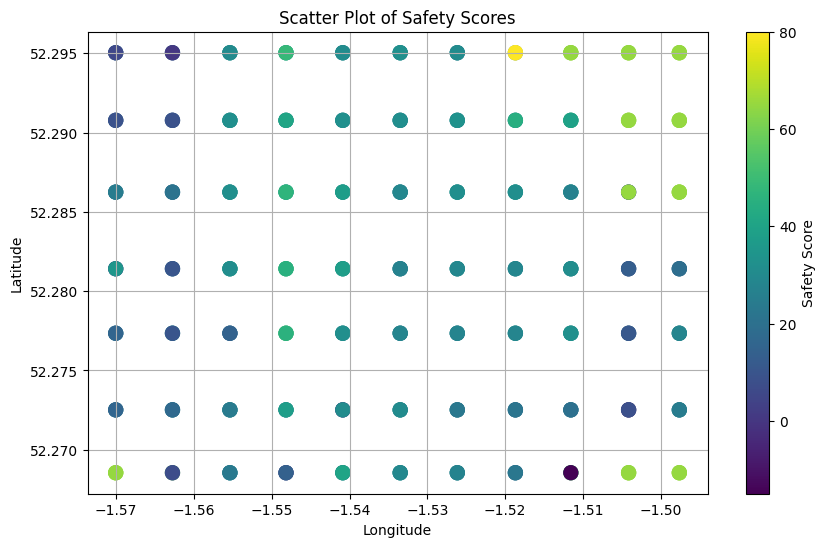

In [ ]:
output_file = "C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\training_set_new.csv"

# Example DataFrame
df = pd.read_csv(output_file)
plt.figure(figsize=(10, 6))

# Scatter plot for safety scores
plt.scatter(df['Longitude'], df['Latitude'], c=df['Safety Score'], cmap='viridis', s=100)  # s is size
plt.colorbar(label='Safety Score')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Scatter Plot of Safety Scores')
plt.grid(True)
plt.show()

38.574827917744585
38.505734295489574
784


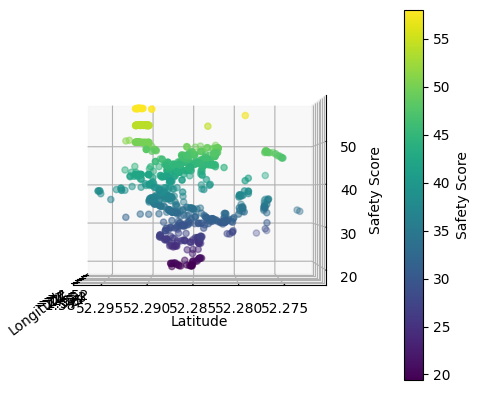

In [144]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame with 'longitude', 'latitude', 'safety score'
output_file = "C:\\Users\\User\\Documents\\GitHub\\proutectapp\\training_set_after_averages.csv"

df = pd.read_csv(output_file)
print(df["Safety Score"].mean())

print(df["Safety Score"].max() - df["Safety Score"].min())

print(len(df))
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x = df['Longitude']
y = df['Latitude']
z = df['Safety Score']

# Scatter plot
sc = ax.scatter(x, y, z, c=z, cmap='viridis')  # Color by safety score, using a colormap
plt.colorbar(sc, label='Safety Score')  # Add colorbar to represent the safety score scale

# Setting the front view
ax.view_init(elev=0, azim=180)  # Adjust azimuth for the desired front orientation


ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Safety Score')

plt.show()


77
31.67446538071906
63.71270194531907


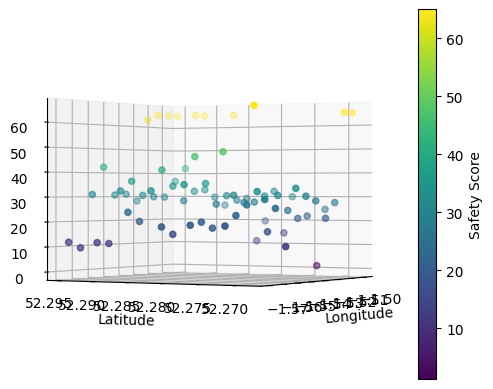

In [134]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame with 'longitude', 'latitude', 'safety score'
output_file = "C:\\Users\\User\\Documents\\GitHub\\proutectapp\\training_set_averages.csv"

df = pd.read_csv(output_file)
print(len(df))
print(df["Safety Score"].mean())
print(df["Safety Score"].max() - df["Safety Score"].min())

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x = df['Longitude']
y = df['Latitude']
z = df['Safety Score']

# Scatter plot
sc = ax.scatter(x, y, z, c=z, cmap='viridis')  # Color by safety score, using a colormap
plt.colorbar(sc, label='Safety Score')  # Add colorbar to represent the safety score scale

# Setting the front view
ax.view_init(elev=0, azim=-150)  # Adjust azimuth for the desired front orientation

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Safety Score')

plt.show()


In [125]:
# Assuming df is your DataFrame with 'longitude', 'latitude', 'safety score'
output_file = "C:\\Users\\User\\Documents\\GitHub\\proutectapp\\training_set_after_averages.csv"
df = pd.read_csv(output_file)
mean_scores = df.groupby(['Longitude', 'Latitude'])['Safety Score'].mean().reset_index()

output_f = "C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\avg_safety_scores.csv"

mean_scores.to_csv(output_f, index=False)

output_f


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\safety_scores_after_averages.csv'

Removing repetition - Max_sum similarity and Maximal Marginal Relevance.

In [ ]:
# keywords = model.extract_keywords(doc)
# model.extract_keywords(doc, keyphrase_ngram_range=(1,3), stop_words='english',
#                        use_maxsum=True, nr_candidates=20, top_n=4)
# model.extract_keywords(doc, keyphrase_ngram_range=(1,3), stop_words='english',
#                        use_mmr=True, diversity=0.9)